In [8]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"egiasuranta","key":"YOUR_API_KEY"}'}

In [9]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [10]:
!pip install kaggle
!kaggle datasets list

ref                                                           title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
rohiteng/amazon-sales-dataset                                 Amazon Sales Dataset                                   4037578  2025-11-23 14:29:37.973000           2952         39  1.0              
wardabilal/spotify-global-music-dataset-20092025              Spotify Global Music Dataset (2009–2025)               1289021  2025-11-11 09:43:05.933000          10224        233  1.0              
khushikyad001/ai-impact-on-jobs-2030                          AI Impact on Jobs 2030                                   87410  2025-11-09 17:58:05.410000           5888        132  1.0              
mayabennet

In [11]:
!kaggle datasets download -d olistbr/brazilian-ecommerce

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
  0% 0.00/42.6M [00:00<?, ?B/s]
100% 42.6M/42.6M [00:00<00:00, 971MB/s]


In [12]:
import zipfile

with zipfile.ZipFile("/content/brazilian-ecommerce.zip", "r") as zip_ref:
    zip_ref.extractall("/content/brazilian-ecommerce")

In [13]:
import pandas as pd

dataset_path = "/content/brazilian-ecommerce/"

orders = pd.read_csv(f"{dataset_path}olist_orders_dataset.csv")
customers = pd.read_csv(f"{dataset_path}olist_customers_dataset.csv")
order_items = pd.read_csv(f"{dataset_path}olist_order_items_dataset.csv")
products = pd.read_csv(f"{dataset_path}olist_products_dataset.csv")
sellers = pd.read_csv(f"{dataset_path}olist_sellers_dataset.csv")
payments = pd.read_csv(f"{dataset_path}olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{dataset_path}olist_order_reviews_dataset.csv")
geolocation = pd.read_csv(f"{dataset_path}olist_geolocation_dataset.csv")

In [14]:
df_merged = order_items.merge(products, on='product_id', how='left') \
                       .merge(orders, on='order_id', how='left')

In [15]:
df_merged = df_merged[['order_purchase_timestamp','product_category_name', 'order_item_id']]

In [16]:
df_merged.isna().any()

,0
order_purchase_timestamp,False
product_category_name,True
order_item_id,False


In [17]:
df_merged['product_category_name'].dropna()

,product_category_name
0,cool_stuff
1,pet_shop
2,moveis_decoracao
3,perfumaria
4,ferramentas_jardim
...,...
112645,utilidades_domesticas
112646,informatica_acessorios
112647,esporte_lazer
112648,informatica_acessorios


In [18]:
df_merged['order_purchase_timestamp'] = pd.to_datetime(df_merged['order_purchase_timestamp'], errors="coerce")

In [19]:
df_merged['order_purchase_month'] = df_merged['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

In [20]:
df_merged = df_merged.groupby(['order_purchase_month','product_category_name']).size().reset_index(name='units')

In [21]:
df_merged

,order_purchase_month,product_category_name,units
0,2016-09-01,beleza_saude,3
1,2016-09-01,moveis_decoracao,2
2,2016-09-01,telefonia,1
3,2016-10-01,alimentos,1
4,2016-10-01,audio,2
...,...,...,...
1257,2018-08-01,sinalizacao_e_seguranca,22
1258,2018-08-01,telefonia,277
1259,2018-08-01,telefonia_fixa,10
1260,2018-08-01,utilidades_domesticas,629


In [22]:
top_product = df_merged.groupby('product_category_name')['units'].sum().nlargest(5).index

In [23]:
df_top_sales =  df_merged[df_merged['product_category_name'].isin(top_product)].copy()

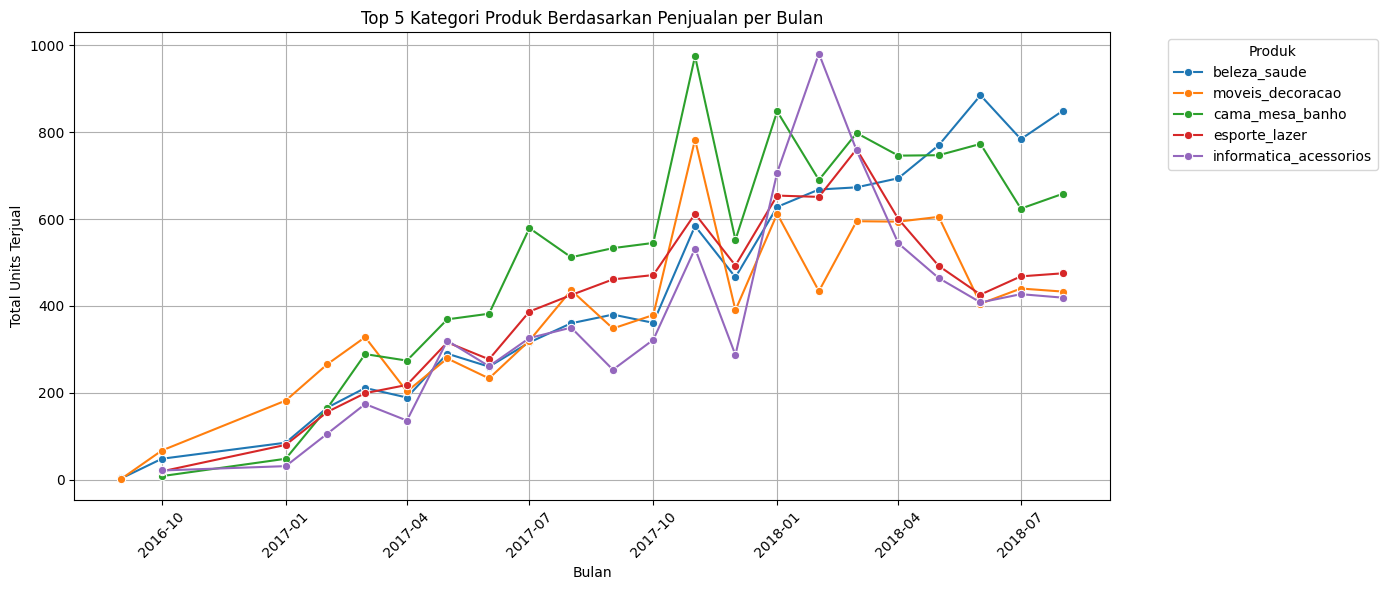

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_top_sales, x = 'order_purchase_month', y = 'units', hue = 'product_category_name', marker = 'o')
plt.title('Top 5 Kategori Produk Berdasarkan Penjualan per Bulan')
plt.xlabel('bulan')
plt.ylabel('Total Units Terjual')
plt.xticks(rotation = 45)
plt.legend(title = 'Produk', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.grid(True)
plt.show()